# Dependencies

In [2]:
# Dependencies
import os
import sys

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import trimesh

# Adding PATH
# Go up THREE levels (project root directory)
project_root = os.path.dirname(os.path.dirname(os.getcwd()))
# Append the new path to sys.path
if project_root not in sys.path:
    sys.path.append(project_root)
    print("Project root added to sys.path")
else:
    print("Project root already in sys.path")

# Matplotlib settings
# plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = ['Liberation Serif', 'serif']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.dpi'] = 100

# Helper function
def customize_axes(ax):
    """
    Function to customize axes with specific settings for spines, labels, grid lines, etc.
    
    Args:
        ax: The axes object to customize
    Return:
        None.
    """
    # Set spine visibility and color
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('gray')
        spine.set_linewidth(1.5)

    # Add horizontal and vertical lines at y=0 and x=0
    ax.axhline(y=0, ls='--', lw=0.5, color='black')
    ax.axvline(x=0, ls='--', lw=0.5, color='black')

Project root added to sys.path


# Import Data: `mol_meshes`, (e)Centroids, Neighbors

Extract from PLY files: `mol_meshes`.

In [3]:
from utils.generate_mol_meshes import import_meshes

# Import either npz files or ply directory (auto-detect)
mol_meshes = import_meshes(path='npt-HK4_meshes', num_processes=None, context='fork')

Loading 1501 meshes with 8 cores: 100%|██████████| 1501/1501 [00:08<00:00, 172.57it/s]


Extract from CSV files: `e_centroids`, `centroids`, `neighbor_candidates` and `neighbor_pairs`.

In [4]:
# Import e-centroids, centroids and neighbor candidates data
df_e_centroids = pd.read_csv('./npt-HK4_e_centroids.csv')
e_centroids = {mol_id: np.array([x, y, z]) for _, mol_id, x, y, z in df_e_centroids.itertuples()}
print(f'{e_centroids=}')

df_centroids = pd.read_csv('./npt-HK4_centroids.csv')
centroids = {mol_id: np.array([x, y, z]) for _, mol_id, x, y, z in df_centroids.itertuples()}
print(f'{centroids=}')

df_neighbor_candidates = pd.read_csv('./npt-HK4_neighbor_candidates.csv')
neighbor_candidates = [(mol_id_1, mol_id_2) for _, mol_id_1, mol_id_2 in df_neighbor_candidates.itertuples()]
print(f'{neighbor_candidates=}')

df_neighbor_pairs = pd.read_csv('./npt-HK4_neighbor_pairs.csv')
neighbor_pairs = [(mol_id_1, mol_id_2) for _, mol_id_1, mol_id_2 in df_neighbor_pairs.itertuples()]
print(f'{neighbor_pairs=}')

e_centroids={1: array([ 15.75727273,   3.93227273, 111.68174545]), 2: array([  4.935     ,   7.26454545, 108.39227273]), 3: array([  7.66909091, 108.07818182,   8.69727273]), 4: array([ 1.52731818, 10.37727273,  1.91959091]), 5: array([55.41954545,  1.17957273, 58.02727273]), 6: array([92.80727273, 66.47681818,  7.53409091]), 7: array([ 68.19590909, 100.06045455,  71.07681818]), 8: array([25.97636364, 68.23909091, 69.13727273]), 9: array([79.10227273, 92.49590909, 84.83954545]), 10: array([17.76818182, 88.35590909, 23.54772727]), 11: array([78.41590909, 97.155     , 21.39      ]), 12: array([73.15636364, 62.76681818, 26.63363636]), 13: array([85.55136364, 65.40545455, 70.38954545]), 14: array([111.43042727,   1.28506364,  47.98727273]), 15: array([105.975     ,  38.25545455,   7.74863636]), 16: array([96.335     , 23.45136364, 85.11772727]), 17: array([ 4.56636364, 45.89227273, 87.15272727]), 18: array([  9.98181818, 110.98357273, 106.86590909]), 19: array([109.45545455,  83.65181818, 

# Data Analysis

Obtain symmetric `neighbor_candidates` and `neighbor_pairs` to plot blocking visualisation and histogram.

In [5]:
from collections import defaultdict


def map_symmetric_neighbors(neighbor_candidates):
    """
    Function to create a symmetric mapping of neighbor candidates.
    
    Parameters
    ----------
        neighbor_candidates: list[tuple[int, int]]
            List of tuples representing neighbor pairs, e.g. [(mol_id_1, mol_id_2),...].
    Returns
    -------
        neighbor_candidates_symmetric: dict[int, list[int]]
            Dictionary mapping each molecule ID to a list of its neighbors.
    """
    neighbor_map = defaultdict(list)
    for mol_id_1, mol_id_2 in neighbor_candidates:
        neighbor_map[mol_id_1].append(mol_id_2) # Pass 1
        neighbor_map[mol_id_2].append(mol_id_1) # Pass 2
        
    neighbor_candidates_symmetric = dict(neighbor_map)
    return neighbor_candidates_symmetric

# Symmetric mapping for neighbor candidates
snc = map_symmetric_neighbors(neighbor_candidates)
print(f'Symmetric neighbor candidates: {snc}')
# Symmetric mapping for neighbor pairs
snp = map_symmetric_neighbors(neighbor_pairs)
print(f'Symmetric_neighbor_pairs: {snp}')

Symmetric neighbor candidates: {1: [2, 4, 18, 244, 359, 847, 943, 1088, 1283, 1308], 2: [1, 3, 4, 18, 127, 226, 704, 780, 984, 1206], 4: [1, 2, 18, 226, 244, 359, 780, 984, 1206, 1330], 18: [1, 2, 4, 127, 231, 282, 610, 850, 943, 1176], 244: [1, 4, 164, 359, 610, 611, 984, 1055, 1370], 359: [1, 4, 244, 247, 471, 490, 497, 787, 1330, 1370], 847: [1, 3, 55, 210, 704, 1206, 1247, 1308, 1330, 1380], 943: [1, 18, 164, 192, 282, 1088, 1176, 1204, 1283, 1308], 1088: [1, 192, 518, 943, 1152, 1283, 1308, 1349, 1461], 1283: [1, 164, 519, 782, 943, 1008, 1088, 1105, 1308, 1370], 1308: [1, 63, 471, 519, 847, 920, 943, 1054, 1088, 1152, 1247, 1283, 1370], 3: [2, 147, 258, 518, 704, 847, 1014, 1380, 1461, 1474], 127: [2, 18, 274, 718, 780, 998, 1013, 1046, 1181, 1245], 226: [2, 4, 219, 274, 513, 704, 718, 878, 1031, 1206], 704: [2, 3, 147, 226, 258, 718, 847, 1014, 1206, 1366, 1461], 780: [2, 4, 127, 274, 610, 660, 984, 1046], 984: [2, 4, 101, 222, 244, 610, 780, 787, 1046, 1343], 1206: [2, 4, 55, 2

## Histogram Checking

Use histogram to investigate the number of bonds formed per molecule.

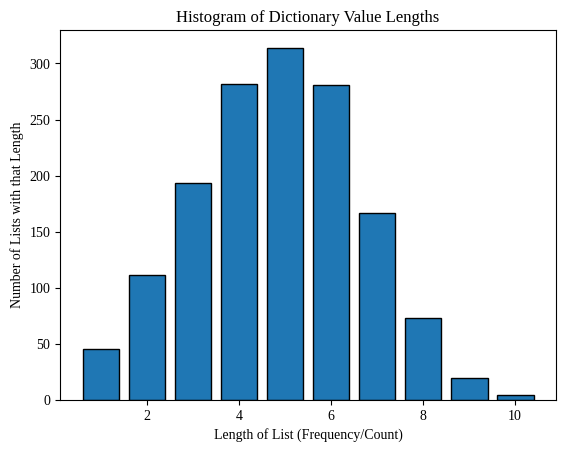

In [49]:
from collections import Counter

data = [len(neighbors) for neighbors in symmetric_neighbor_pairs.values()]
counts = Counter(data)
x_values = sorted(counts.keys())
y_counts = [counts[val] for val in x_values]

# 2. Plot as a bar chart
plt.bar(x_values, y_counts, width=0.8, align='center', edgecolor='black')
plt.xlabel('Length of List (Frequency/Count)')
plt.ylabel('Number of Lists with that Length')
plt.title('Histogram of Dictionary Value Lengths')
plt.show()

In [ ]:
# Random data
x = np.linspace(-10, 10, 100)
y = x**3

# Create figure and define subplots
fig, ax = plt.subplots(1, 1, figsize=(7, 6))

# Plot graph
ax.scatter(x, y, label='Data points', marker='^', color='darkblue', s=30)
ax.plot(x, y, label=r"$x^3$", c='crimson')
ax.set_title(r"Plot of function, $f(x)=x^3$", fontsize=14)

# Customize the appearance of the axes
customize_axes(ax)
ax.grid(True, alpha=0.3)
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')

ax.set_xlim(-5, 5)
ax.set_ylim(-100, 100)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1.0))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
ax.yaxis.set_major_locator(ticker.MultipleLocator(25))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(5))


# Legend
ax.legend(loc='best', frameon=True, facecolor='white')

# Show graph
plt.tight_layout()
plt.savefig('template_plot.svg', bbox_inches='tight')
plt.show()

## Visual Checking

Use `neighbor_candidates` and `neighbor_pairs` to visualise blocking.

In [ ]:
from matplotlib import colors as mcolors
import numpy as np

def get_distinct_colors(n, alpha=200, method='hsv'):
    """
    Return a list of n RGBA colors in 0-255 int format.
    method: 'hsv' (even hue spacing) or 'matplotlib_tab' (uses tab20).
    alpha: 0-255
    """
    if n <= 0:
        return []
    if method == 'matplotlib_tab':
        # tab20 has up to 20 distinct categorical colors
        cmap = plt.get_cmap('tab20')
        colors = [cmap(i) for i in range(n)]
        # cmap returns RGBA floats 0-1 -> convert
        colors = [(int(r*255), int(g*255), int(b*255), int(a*255)) for (r,g,b,a) in colors]
        return colors
    # default: evenly spaced HSV hues (good for 1..11)
    hues = np.linspace(0, 1, n, endpoint=False)
    sats = 0.65   # saturation
    vals = 0.90   # value (brightness)
    colors = []
    for h in hues:
        rgb = mcolors.hsv_to_rgb((h, sats, vals))  # returns 3 floats 0..1
        colors.append((int(rgb[0]*255), int(rgb[1]*255), int(rgb[2]*255), int(alpha)))
    return colors

In [26]:
import time
import ast

def view_molecule(mol_id, e_centroids, mol_meshes, 
                  symmetric_neighbor_candidates, 
                  symmetric_neighbor_pairs,
                  view_unpaired_mols=None,
                  distinct_color=False):
    """
    Function to visualize a molecule with its mesh, e-centroid, centroid, and neighbors.
    
    Parameters
    ----------
        mol_id: int
            The ID of the molecule to visualize.
        e_centroids: dict[int, np.ndarray]
            Dictionary mapping molecule IDs to their e-centroid coordinates.
        mol_meshes: dict[int, trimesh.Trimesh]
            Dictionary mapping molecule IDs to their mesh objects.
        neighbor_candidates: dict[int, list[int]]
            Dictionary mapping each molecule ID to a list of its neighbor candidates.
        neighbor_pairs: dict[int, list[int]]
            Dictionary mapping each molecule ID to a list of its confirmed neighbors.
        view_unpaired_mols: boolean, int, list[int], optional
            List of molecule IDs to specifically view. If True, view all unpaired neighbors.
            If False, view no unpaired neighbors. If None, prompt user for input.
        distinct_color: boolean, optional
            If True, use a monotone color scheme for the meshes for higher contrast.
    Returns
    -------
        None. Displays a 3D plot of the molecule and its neighbors.
    """
    # Parameters
    snc_ids = symmetric_neighbor_candidates[mol_id]
    snp_ids = symmetric_neighbor_pairs[mol_id]
    exclusive_ids = sorted(list(set(snc_ids).difference(set(snp_ids))))
    
    # Show to user paired neighbors
    print(f'Neighbor pairs for molecule {mol_id}: {snp_ids}\n{'-'*40}'); time.sleep(1)
    
    # -----------------------------
    # User WANT TO A FEW, show the number of unpaired neighbors specified by user
    if isinstance(view_unpaired_mols, int): 
        if view_unpaired_mols < 0:
            print("Please enter a non-negative integer for the number of unpaired neighbors to view."); return None
        elif view_unpaired_mols > len(exclusive_ids):
            print(f"Only {len(exclusive_ids)} unpaired neighbors available. Showing all of them.")
            user_select_ids = exclusive_ids
        else:
            user_select_ids = exclusive_ids[:view_unpaired_mols]
    
    # User WANT TO SEE ALL (True), show all unpaired neighbors 
    elif view_unpaired_mols is True: user_select_ids = exclusive_ids

    # User DOESN'T WANT TO SEE ANY (False), show no unpaired neighbors
    elif view_unpaired_mols is False: user_select_ids = []
        
    # User DOES NOT SPECIFY (None), prompt user which unpaired neighbors to view
    elif view_unpaired_mols is None:
        print("Select the non-paired neighbors to view. Use the following format:\n\
            - For specific molecules: '[101, 104, 403]'\n\
            - For all neighbors: 'all'\n\
            - For no neighbors: ''\n"); time.sleep(1)
        print(f'Non-paired neighbors are: {exclusive_ids}'); time.sleep(1) # Display non-pair neighbor to user
        view_ids = input("View: ") # User chooses which molecules to view
        # Process user input
        try: 
            # User chooses to view all neighbors
            if view_ids.strip().lower() == 'all': user_select_ids = exclusive_ids
            # User does not want to view any neighbors
            elif view_ids == '': user_select_ids = []
            # User chooses normally
            else: user_select_ids = ast.literal_eval(view_ids)
            # Check if user input is valid
            if not set(user_select_ids).issubset(set(exclusive_ids)): # User enters molecule NOT in neighbor list
                print(f"{'-'*40}\nSelected molecule ID not in neighbor list. Please try again."); return None
        except:
            # Other errors in user input
            print(f"{'-'*40}\nInvalid input format. Please use the specified format."); return None
    
    # User DOES SPECIFY (list), use their selection of unpaired neighbors
    else:
        user_select_ids = view_unpaired_mols
        # Check if user input is valid
        if not set(user_select_ids).issubset(set(exclusive_ids)): 
            print(f"Selected molecule ID not in neighbor list. Please try again."); return None
    # -----------------------------

    # Verified successful input
    print(f"You have selected: {user_select_ids}\n{'-'*40}"); time.sleep(1) 
    
    # Overall molecule meshes to show
    meshes_to_show_ids = sorted([mol_id] + snp_ids + user_select_ids)
    meshes_to_show = [mol_meshes[ids] for ids in meshes_to_show_ids]
    print(f'You are now viewing molecules {meshes_to_show_ids}')

    # Line mesh for unblocked neighbors
    meshes_lines = []
    target_coord = e_centroids[mol_id]
    for ids in snp_ids:
        neighbor_coord = e_centroids[ids]
        segment = [target_coord, neighbor_coord]
        cyl = trimesh.creation.cylinder(radius=0.05, segment=segment, sections=24)
        cyl.visual.face_colors = [255, 255, 0, 100] # Yellow color
        meshes_lines.append(cyl)
        
    # Palette color scheme for higher contrast
    if distinct_color == True:
        palette = get_distinct_colors(len(meshes_to_show), alpha=200, method='hsv')
        for mesh, color in zip(meshes_to_show, palette):
            num_vertices = len(mesh.vertices)
            num_faces = len(mesh.faces)
            mesh.visual.face_colors = np.tile(color, (num_vertices, 1))
            mesh.visual.face_colors = np.tile(color, (num_faces, 1))
    
    meshes = trimesh.util.concatenate(meshes_to_show  + meshes_lines)
    scene = trimesh.Scene(meshes)
    
    return scene.show()

In [80]:
# For molecule ID 10
# print(f'symmetric_neighbor_candidates = {snc[10]}')
# print(f'symmetric_neighbor_pairs = {snp[10]}')
# print(f'intersect neighbor candidates = {list(set(snc[10]).intersection(set(snp[10])))}')
# print(f'exclusive neighbor candidates = {list(set(snc[10]).difference(set(snp[10])))}')

In [35]:
# PROBLEM: Molecule does not consider itself when blocking neighbors
view_molecule(mol_id=100, e_centroids=e_centroids, mol_meshes=mol_meshes, 
                             symmetric_neighbor_candidates=snc, symmetric_neighbor_pairs=snp, 
                             view_unpaired_mols=5, distinct_color=True)

Neighbor pairs for molecule 100: [552, 838, 1414]
----------------------------------------
You have selected: [113, 237, 741, 1034, 1048]
----------------------------------------
You are now viewing molecules [100, 113, 237, 552, 741, 838, 1034, 1048, 1414]
